# S&P 500 Sector Trend Analysis and Prediction
## Baigali Nyamdulam - 04/01/2026

### Import libraries and load the data

In [22]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import mean_squared_error, r2_score
import seaborn as sns
import matplotlib.pyplot as plt
import datetime as dt
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Dropout
import warnings
warnings.filterwarnings('ignore')
df = pd.read_csv('data/raw/sp500_500companies_10years_20260401.csv')
print(df.shape)

(1257500, 18)


### Slight Data Cleaning

In [23]:
df['Date'] = pd.to_datetime(df['Date'])
df1=df.drop(columns=['Adj Close', 'Headquarters Location', 'Date added', 'CIK', 'Founded', 'Sector', 'Exchange', 'HQ_Location', 'Security'])
na_counts = df1.isnull().sum()
cleaned_df1 = df1.dropna()
print(cleaned_df1.shape)
na_counts_df1 = cleaned_df1.isnull().sum()


(1217883, 9)


### Feature Engineering

In [24]:
#Average price of a stock in a given day. This feature will be used in other features. Apparently, the true average is calculated by taking the total dollars traded and 
#dividing it by total number of shares traded, but we don't have that information. Regardless, below calculation should give a good approximation.
cleaned_df1['Avg of the day'] = (cleaned_df1['High'] + cleaned_df1['Low'] + cleaned_df1['Close'])/3
#Below feature is the daily price range change. The limitation is when a stock price has large gaps between highs and lows but closes around the same price as 
#the opening, it overestimates the volatility. If I try to take the difference between opening and closing, I have even less accuracy for volatility because
#I would be disregarding the movements that happen overnight.
cleaned_df1['Daily Volatility'] = (cleaned_df1['High'] - cleaned_df1['Close'])/cleaned_df1['Close']

#Below codes are doing what's called log returns. It essentially normalizes the stock prices so I don't need to deal with companies with wildly different stock prices.
#Also log returns can be added across a period. + log return indicates increase (in price) and - log return indicates (decrease in price)
cleaned_df1 = cleaned_df1.sort_values(by=["Ticker", "Date"])
cleaned_df1["prev_close"] = cleaned_df1.groupby("Ticker")["Close"].shift(1)
cleaned_df1["log_return"] = np.log(cleaned_df1["Close"] / cleaned_df1["prev_close"])
cleaned_df1 = cleaned_df1.dropna(subset=["log_return"])
cleaned_df1["intraday_return"] = np.log(cleaned_df1["Close"] / cleaned_df1["Open"])
cleaned_df1["overnight_return"] = np.log(cleaned_df1["Open"] / cleaned_df1["prev_close"])
cleaned_df1["range"] = (cleaned_df1["High"] - cleaned_df1["Low"]) / cleaned_df1["Close"]
cleaned_df1["vol_20d_avg"] = (cleaned_df1.groupby("Ticker")["Volume"].transform(lambda x: x.rolling(window=20, min_periods=20).mean()))

#Below features are volume based features that will help us detect whether the stock is actually being pressured to be sold or bought. High volume and increase in Avg price
#would indicate people are buying and and high volume and decrease in avg price would indicate people are selling. Also, volume spikes are being measured specifically.
cleaned_df1["volume_spike"] = cleaned_df1["Volume"] / cleaned_df1["vol_20d_avg"]
cleaned_df1["vw_return"] = cleaned_df1["log_return"] * cleaned_df1["volume_spike"]
cleaned_df1["price_change"] = cleaned_df1["Close"] - cleaned_df1["Open"]
cleaned_df1["signed_volume"] = cleaned_df1["price_change"] * cleaned_df1["Volume"]
cleaned_df1["up"] = (cleaned_df1["log_return"] > 0).astype(int)

print(cleaned_df1)

              Date        Open        High         Low       Close     Volume  \
22636   2016-04-04   37.250340   37.435114   36.769928   36.963940  2958100.0   
22637   2016-04-05   36.705265   36.853083   36.206375   36.271046  1900700.0   
22638   2016-04-06   36.298770   37.185682   36.187903   37.176445  1566600.0   
22639   2016-04-07   36.853088   37.047099   36.261813   36.465065  1373800.0   
22640   2016-04-08   36.668302   36.926987   36.400383   36.529724  1106300.0   
...            ...         ...         ...         ...         ...        ...   
1257495 2026-03-26  158.860001  159.649994  156.100006  156.139999  2034000.0   
1257496 2026-03-27  156.279999  157.399994  153.130005  153.960007  1701600.0   
1257497 2026-03-30  155.190002  156.309998  152.899994  154.589996  1268500.0   
1257498 2026-03-31  156.020004  156.990005  152.589996  155.479996  1699400.0   
1257499 2026-04-01  157.190002  155.524994  152.610001  154.610001   458483.0   

        Ticker             

### Simple Visualizations

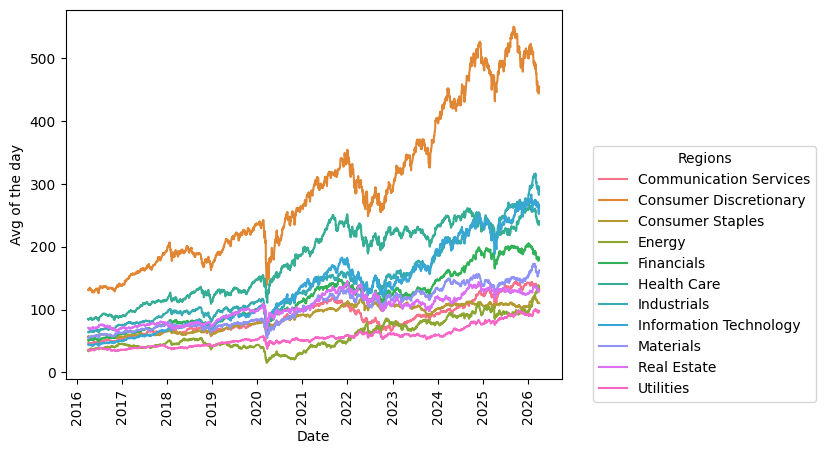

In [25]:
df2 = cleaned_df1.groupby(['GICS Sector', 'Date'])[['Avg of the day']].mean()
sns.lineplot(data=df2, x='Date', y='Avg of the day', hue='GICS Sector')
plt.tick_params(axis='x', labelrotation=90)
plt.legend(bbox_to_anchor = (1.05, 0.65), title='Regions')
plt.show()

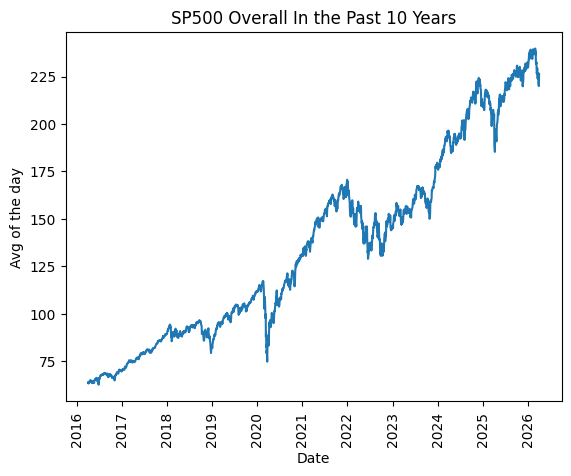

In [26]:
df2_1 = cleaned_df1.groupby(['Date'])[['Avg of the day']].mean()
sns.lineplot(data=df2_1, x='Date', y='Avg of the day')
plt.tick_params(axis='x', labelrotation=90)
plt.title('SP500 Overall In the Past 10 Years')
plt.show()

In [27]:
#df3 = cleaned_df1.groupby(['GICS Sector', 'Date'])[['Daily Volatility']].mean()
#df3['Daily Volatility'] = df3[df3['Daily Volatility'] > 0.02]
#sns.lineplot(data=df3, x='Date', y='Daily Volatility', hue='GICS Sector')
#plt.tick_params(axis='x', labelrotation=90)
#plt.legend(bbox_to_anchor = (1.05, 0.65), title='Regions')
#plt.show()

### Below visualization is the graph of how each sector performed considering their 10 day rolling average of the log returns. 

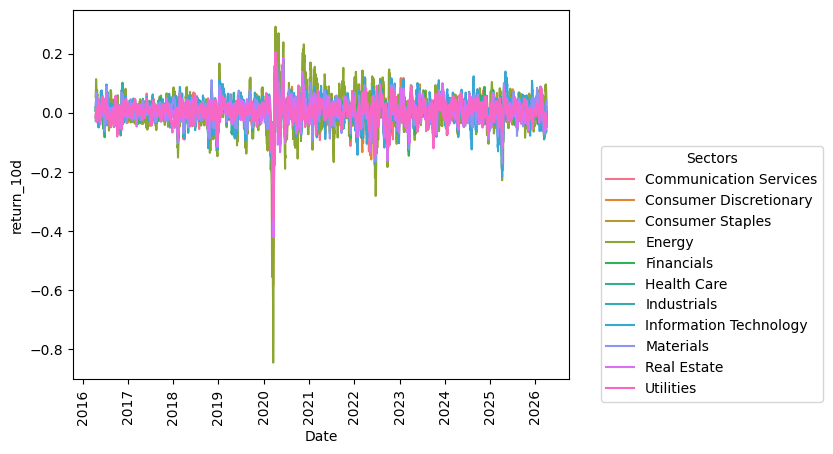

In [28]:
cleaned_df1["return_10d"] = (cleaned_df1.groupby("Ticker")[["log_return"]].rolling(10).sum().reset_index(level=0, drop=True))
sector_momentum = cleaned_df1.groupby(["Date", "GICS Sector"])[["return_10d"]].mean()
sns.lineplot(data=sector_momentum, x='Date', y='return_10d', hue='GICS Sector')
plt.tick_params(axis='x', labelrotation=90)
plt.legend(bbox_to_anchor = (1.05, 0.65), title='Sectors')
plt.show()

### More Feature Engineering for the Sectors.

In [29]:
sector_df = cleaned_df1.groupby(["Date", "GICS Sector"]).agg({
    "log_return": ["mean", "std"],
    "intraday_return": ["mean"],
    "overnight_return": ["mean"],
    "range": ["mean"],
    "volume_spike": ["mean", "max"],
    "vw_return": ["mean"],
    "signed_volume": ["mean", "std"],
    "up": ["mean"]
}).reset_index()

# Flatten column names
sector_df.columns = [
    "_".join(col).strip("_") for col in sector_df.columns.values
]

# Rename for clarity
sector_df = sector_df.rename(columns={
    "up_mean": "breadth",
    "log_return_mean": "log_return"
})

# Sort
sector_df = sector_df.sort_values(["GICS Sector", "Date"])

sector_df["target"] = sector_df.groupby("GICS Sector")["log_return"].shift(-1)

features = [
    "intraday_return_mean",
    "overnight_return_mean",
    "range_mean",
    "volume_spike_mean",
    "volume_spike_max",
    "vw_return_mean",
    "signed_volume_mean",
    "signed_volume_std",
    "log_return_std", 
    "breadth"
]
print(sector_df)

            Date             GICS Sector  log_return  log_return_std  \
0     2016-04-04  Communication Services   -0.008666        0.013934   
11    2016-04-05  Communication Services   -0.008569        0.008069   
22    2016-04-06  Communication Services    0.005537        0.009102   
33    2016-04-07  Communication Services   -0.015954        0.010528   
44    2016-04-08  Communication Services   -0.001306        0.009800   
...          ...                     ...         ...             ...   
27609 2026-03-26               Utilities    0.003509        0.011142   
27620 2026-03-27               Utilities    0.005010        0.013277   
27631 2026-03-30               Utilities    0.006953        0.015851   
27642 2026-03-31               Utilities    0.001848        0.015702   
27653 2026-04-01               Utilities    0.005380        0.007466   

       intraday_return_mean  overnight_return_mean  range_mean  \
0                 -0.009379               0.000713    0.025752   
11 

### RNN and RMSE For Each Sector

In [41]:
WINDOW = 30

def create_sequences(df, features, target, window):
    X, y = [], []
    
    for i in range(len(df) - window):
        X.append(df[features].iloc[i:i+window].values)
        y.append(df[target].iloc[i+window])
        
    return np.array(X), np.array(y)

rnn_results = []
rnn_all = []
for sector in sector_df["GICS Sector"].unique():
    
    df_s = sector_df[sector_df["GICS Sector"] == sector].copy()
    df_s = df_s.dropna(subset=features + ["target"])
    
    if len(df_s) < 100:
        continue

    # Normalize
    scaler = StandardScaler()
    df_s[features] = scaler.fit_transform(df_s[features])
    
    # Build sequences
    X, y = create_sequences(df_s, features, "target", WINDOW)
    
    if len(X) < 50:
        continue

    # Train/test split (time-based)
    split = int(len(X) * 0.8)
    
    X_train, X_test = X[:split], X[split:]
    y_train, y_test = y[:split], y[split:]
    
    
    model = Sequential([
        SimpleRNN(64, activation='tanh', input_shape=(WINDOW, len(features))),
        Dropout(0.2),
        Dense(32, activation='relu'),
        Dense(1)
    ])
    
    model.compile(optimizer='adam', loss='mse')
    
    model.fit(
        X_train, y_train,
        epochs=20,
        batch_size=32,
        verbose=0
    )
    
    preds = model.predict(X_test)
    rnn_all.append(pd.DataFrame({
    "sector": sector,
    "actual": y_test,
    "pred_rnn": preds.flatten()}))
    
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    
    rnn_results.append([sector, rmse])



rnn_df = pd.DataFrame(rnn_results, columns=["sector", "rmse"])
print(rnn_df)

16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 65ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 60ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step
                    sector      rmse
0   Communication Services  0.064898
1   Consumer Discretionary  0.016767
2         Consumer Staples  0.018029
3                   Energy  0.019867
4               Financials  0.035461
5              Health Care  0.033895
6              Industrials  0.033787
7   Information Technology  0.028886
8                Materials  0.017359
9              Real Estate  0.028527
10               Utilities  0.012518


### Train Random Forest Using the Sector Specific DF

In [42]:
sector_df["target"] = sector_df.groupby("GICS Sector")["log_return"].shift(-1)
features = [
    "intraday_return_mean",
    "overnight_return_mean",
    "range_mean",
    "volume_spike_mean",
    "volume_spike_max",
    "vw_return_mean",
    "signed_volume_mean",
    "signed_volume_std",
    "log_return_std", 
    "breadth"
]
rf_results = []
rf_all = []
for sector in sector_df["GICS Sector"].unique():
    df_s = sector_df[sector_df["GICS Sector"] == sector].copy()

    X = df_s[features]
    y = df_s["target"]

    data = pd.concat([X, y], axis=1).dropna()
    X = data[features]
    y = data["target"]

    split = int(len(X) * 0.8)

    X_train, X_test = X.iloc[:split], X.iloc[split:]
    y_train, y_test = y.iloc[:split], y.iloc[split:]

    model = RandomForestRegressor(n_estimators=200, random_state=42) #Regressor because "target" is log_return which is not binary (0, 1)
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    rf_all.append(pd.DataFrame({"sector": sector,"actual": y_test,"pred_rf": preds}))
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    rf_results.append([sector, "random_forest", rmse])

rf_df = pd.DataFrame(rf_results, columns=["sector", "method", "rmse"])
print(rf_df)

                    sector         method      rmse
0   Communication Services  random_forest  0.011039
1   Consumer Discretionary  random_forest  0.013412
2         Consumer Staples  random_forest  0.009325
3                   Energy  random_forest  0.015375
4               Financials  random_forest  0.012049
5              Health Care  random_forest  0.010311
6              Industrials  random_forest  0.012160
7   Information Technology  random_forest  0.016136
8                Materials  random_forest  0.011830
9              Real Estate  random_forest  0.012559
10               Utilities  random_forest  0.010326


### Time Series Forecasts

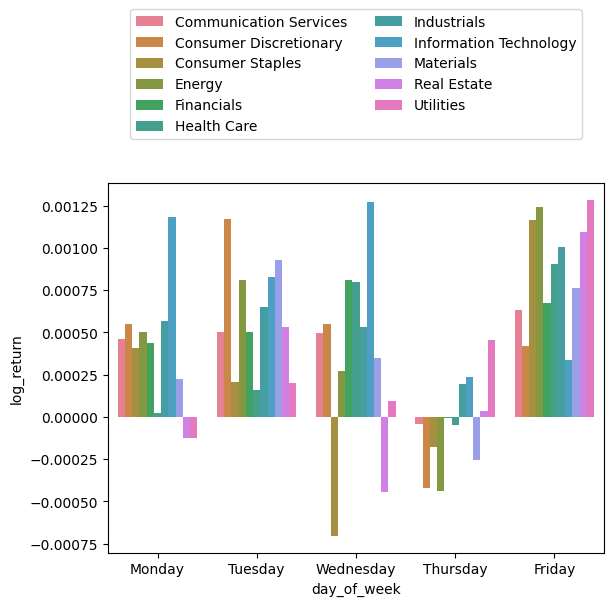

In [32]:
sector_df['day_of_week'] = sector_df['Date'].dt.day_name()
avg_sector_log_return_day_of_week = sector_df.groupby(['day_of_week', 'GICS Sector'])[['log_return']].mean()

# Create bar plot comparing weekday patterns
# TODO: Create bar plot showing average sales by day of week
order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday']
sns.barplot(data=avg_sector_log_return_day_of_week, x='day_of_week', y='log_return', hue='GICS Sector', order=order)
plt.legend(bbox_to_anchor=(0.5, 1.1), loc='lower center', ncol=2)
plt.show()

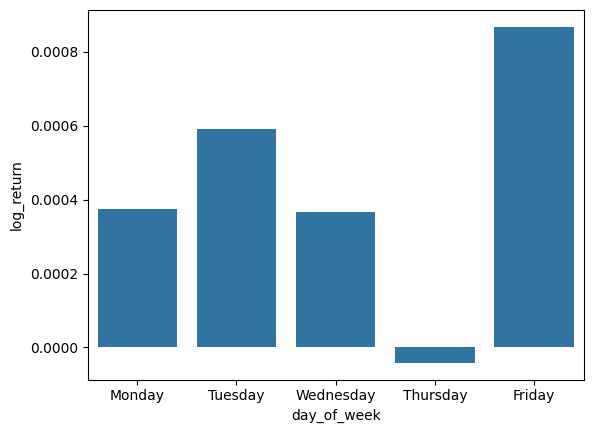

In [33]:
sector_df['day_of_week'] = sector_df['Date'].dt.day_name()
avg_sector_log_return_day_of_week1 = sector_df.groupby(['day_of_week'])[['log_return']].mean()

# Create bar plot comparing weekday patterns
# TODO: Create bar plot showing average sales by day of week
order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday']
sns.barplot(data=avg_sector_log_return_day_of_week1, x='day_of_week', y='log_return', order=order)
plt.show()

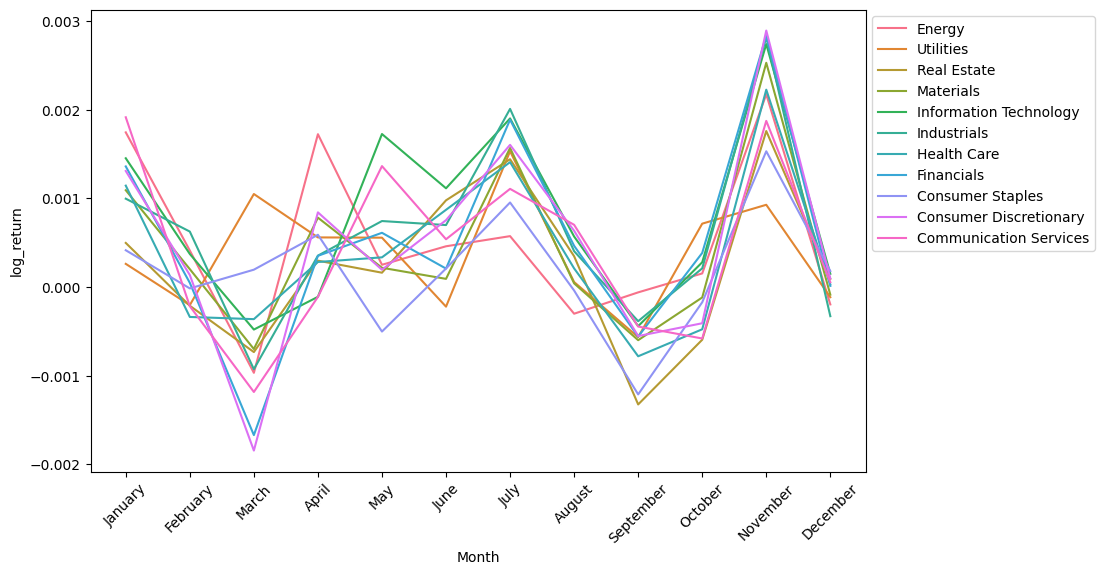

In [34]:
sector_df['Month'] = sector_df['Date'].dt.month_name()
avg_sector_log_return_by_month = (
    sector_df.groupby(['Month', 'GICS Sector'])['log_return']
    .mean()
    .reset_index()
)  # Group by month and calculate mean
month_order = [
    'January','February','March','April','May','June',
    'July','August','September','October','November','December'
]
avg_sector_log_return_by_month['Month'] = pd.Categorical(avg_sector_log_return_by_month['Month'], categories=month_order, ordered=True)
log_return_avg_sector_monthly = avg_sector_log_return_by_month.sort_values('Month')
# Create visualization
# TODO: Create line plot showing monthly patterns for both products
plt.figure(figsize=(10,6))
sns.lineplot(data=log_return_avg_sector_monthly, x='Month', y='log_return', hue='GICS Sector', errorbar=None)
plt.legend(bbox_to_anchor=(1.0, 1.0))
plt.xticks(rotation=45)
plt.show()

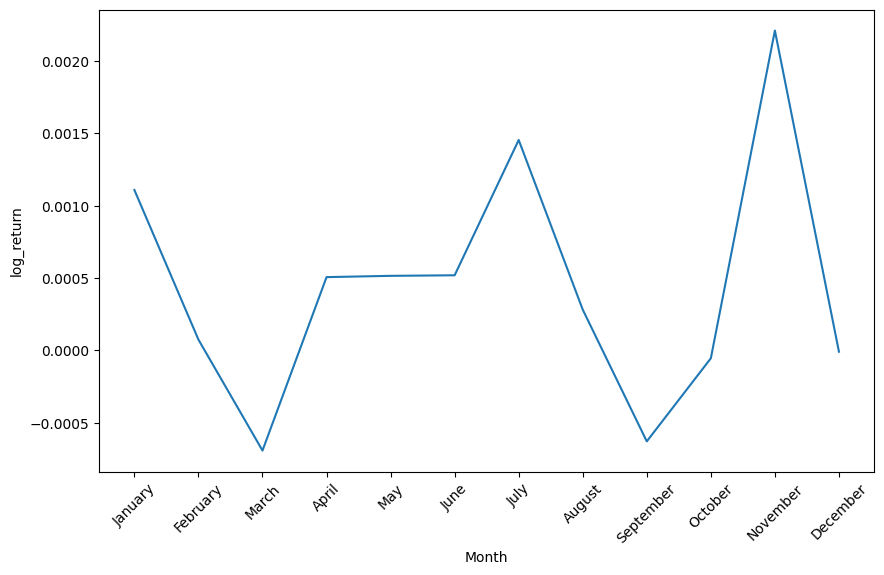

In [35]:
avg_sector_log_return_by_month1 = (sector_df.groupby(['Month'])[['log_return']].mean().reset_index())  # Group by month and calculate mean
month_order = [
    'January','February','March','April','May','June',
    'July','August','September','October','November','December'
]
avg_sector_log_return_by_month1['Month'] = pd.Categorical(avg_sector_log_return_by_month1['Month'], categories=month_order, ordered=True)
log_return_avg_sector_monthly1 = avg_sector_log_return_by_month1.sort_values('Month')
# Create visualization
# TODO: Create line plot showing monthly patterns for both products
plt.figure(figsize=(10,6))
sns.lineplot(data=log_return_avg_sector_monthly1, x='Month', y='log_return', errorbar=None)
plt.xticks(rotation=45)
plt.show()

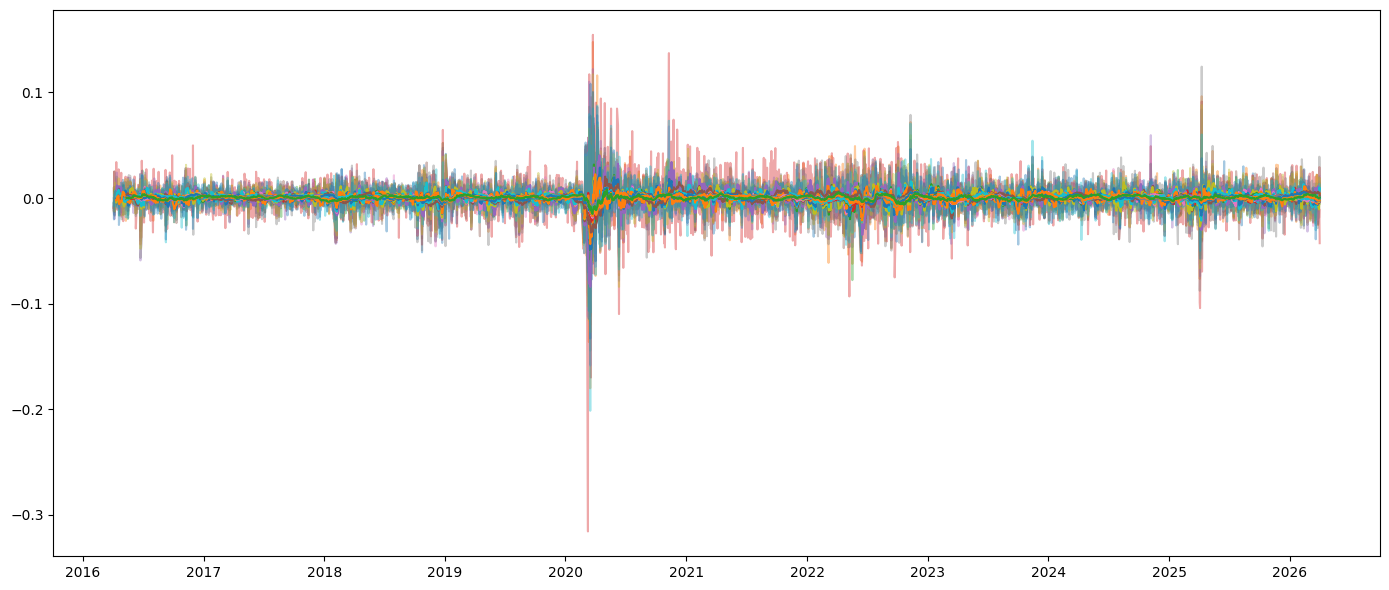

In [36]:
start_date = '2016-04-01' #Update this date to your dates. The data mining code literally scrapes the data of the last ten years from the day you run that code.
end_date = '2026-03-31' #I ran my code on the 1st of April, which is why my beginning date is April 1st, 2016. 
date_range = pd.date_range(start=start_date, end=end_date, freq='D')
lr_ts = (sector_df.groupby(['Date', 'GICS Sector'])['log_return'].sum().unstack())  # columns = sectors.reindex(date_range, fill_value=0))
lr_ma7 = lr_ts.rolling(window=7).mean()
lr_ma30 = lr_ts.rolling(window=30).mean()
fig, axes = plt.subplots(figsize=(14, 6))

# TODO: Plot original, 7-day MA, and 30-day MA for product 1
axes.plot(lr_ts.index, lr_ts.values, alpha=0.4, label='Daily Sales')
axes.plot(lr_ma7.index, lr_ma7.values, label='7-Day MA')
axes.plot(lr_ma30.index, lr_ma30.values, label='30-Day MA')
plt.tight_layout()
plt.show()

### Time Series Decomposition

In [37]:
for sector in lr_ts.columns:
    log_return_decomposition = seasonal_decompose(
        lr_ts[sector],
        model='additive',
        period=5  # see note below
    )
    #For seasonal, observed, trend, and residual plots please uncomment below lines (will display 4 plots for each sector)
    #if log_return_decomposition is not None:
        #fig, axes = plt.subplots(4, 1, figsize=(14, 10))
        #log_return_decomposition.observed.plot(ax=axes[0], title=f'{sector} - Original')
        #log_return_decomposition.trend.plot(ax=axes[1], title='Trend')
        #log_return_decomposition.seasonal.plot(ax=axes[2], title='Seasonal')
        #log_return_decomposition.resid.plot(ax=axes[3], title='Residual')
        #plt.tight_layout()
        #plt.show()

### Log Return Forcasting for each sector beginning March 31, 2026. It uses the entire 10 year data.

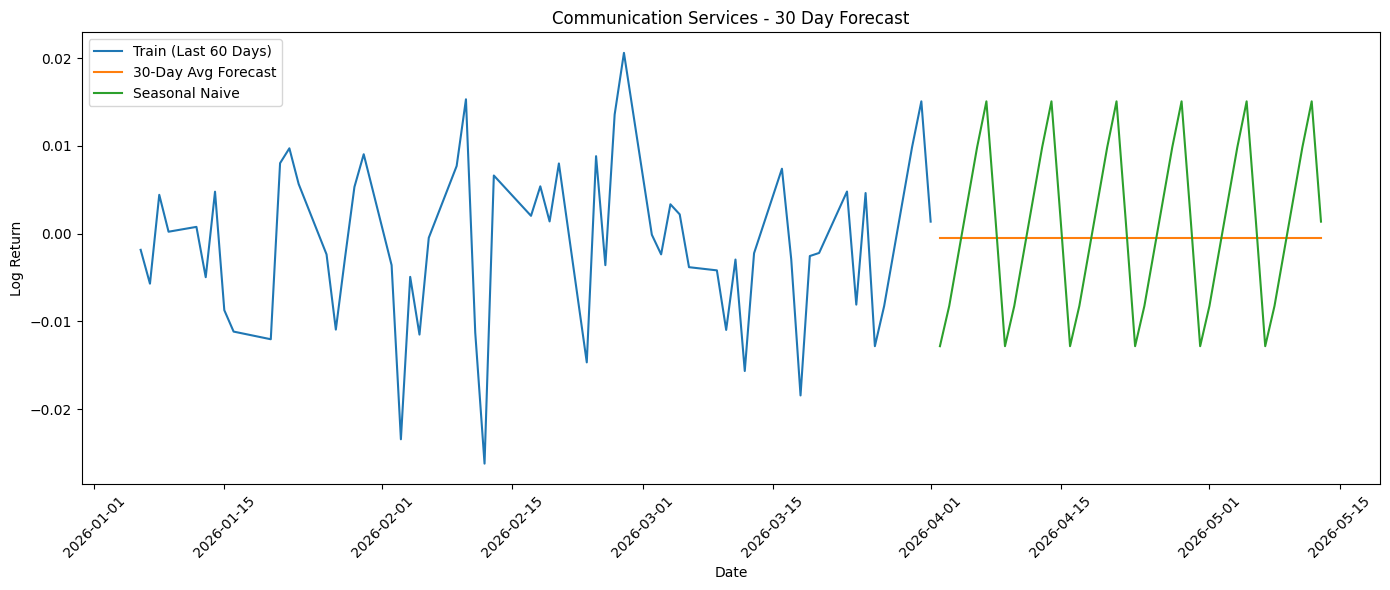

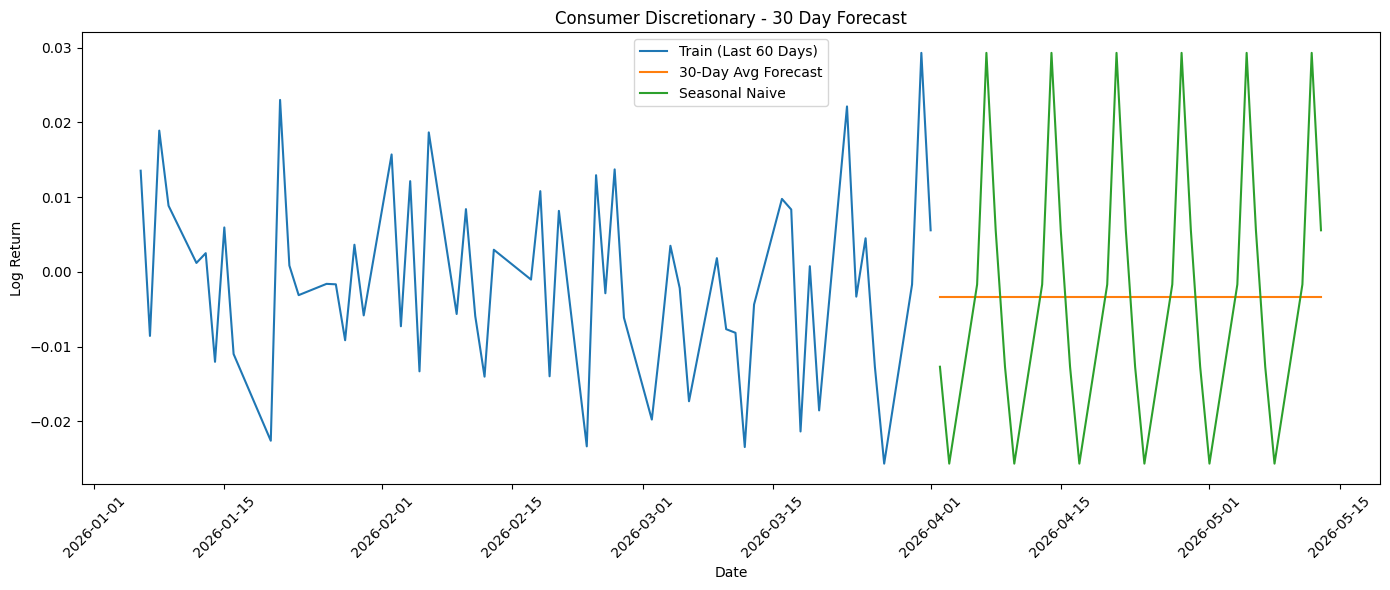

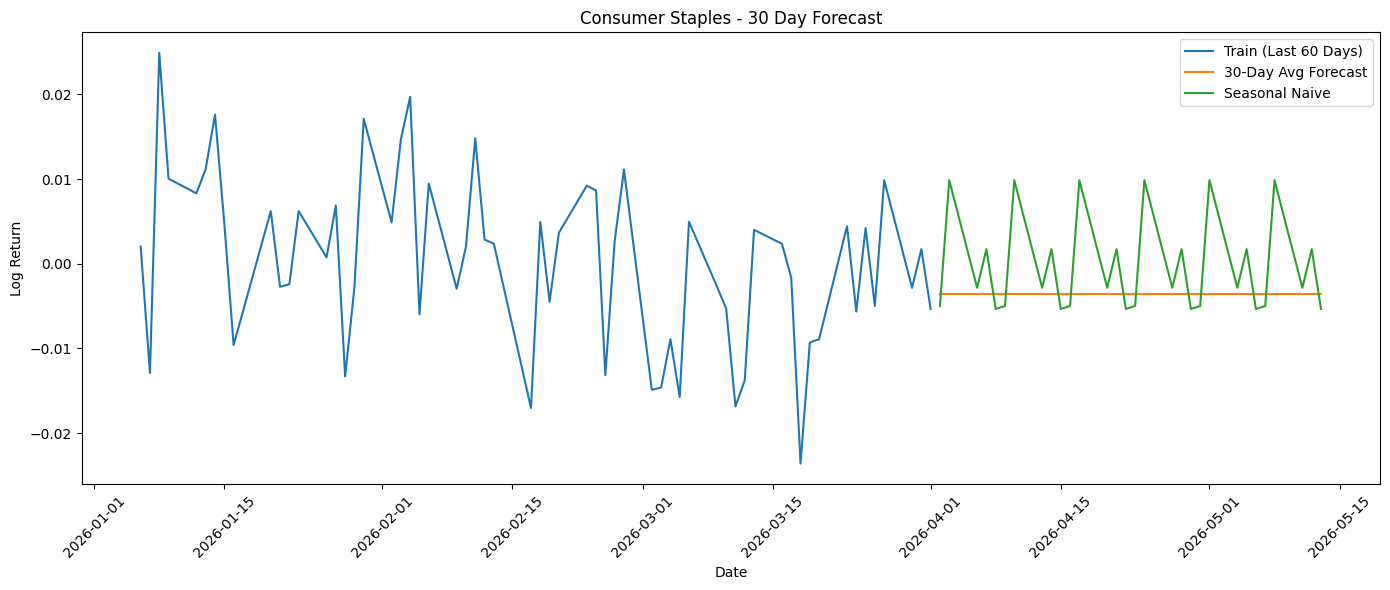

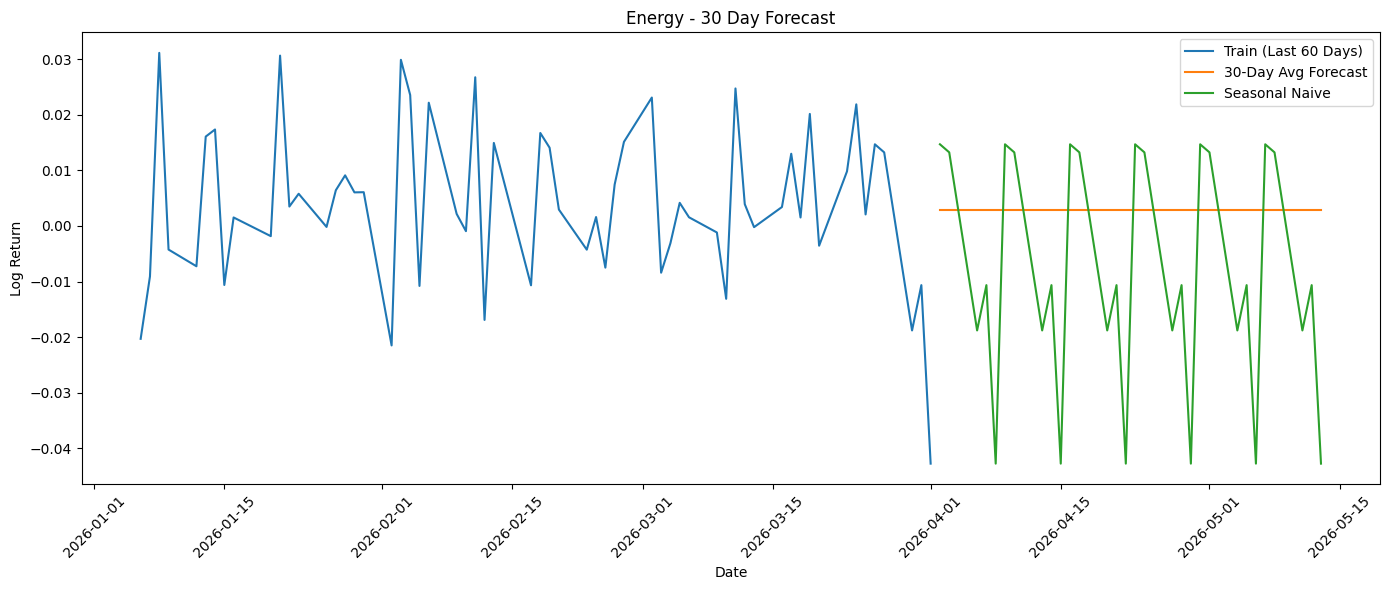

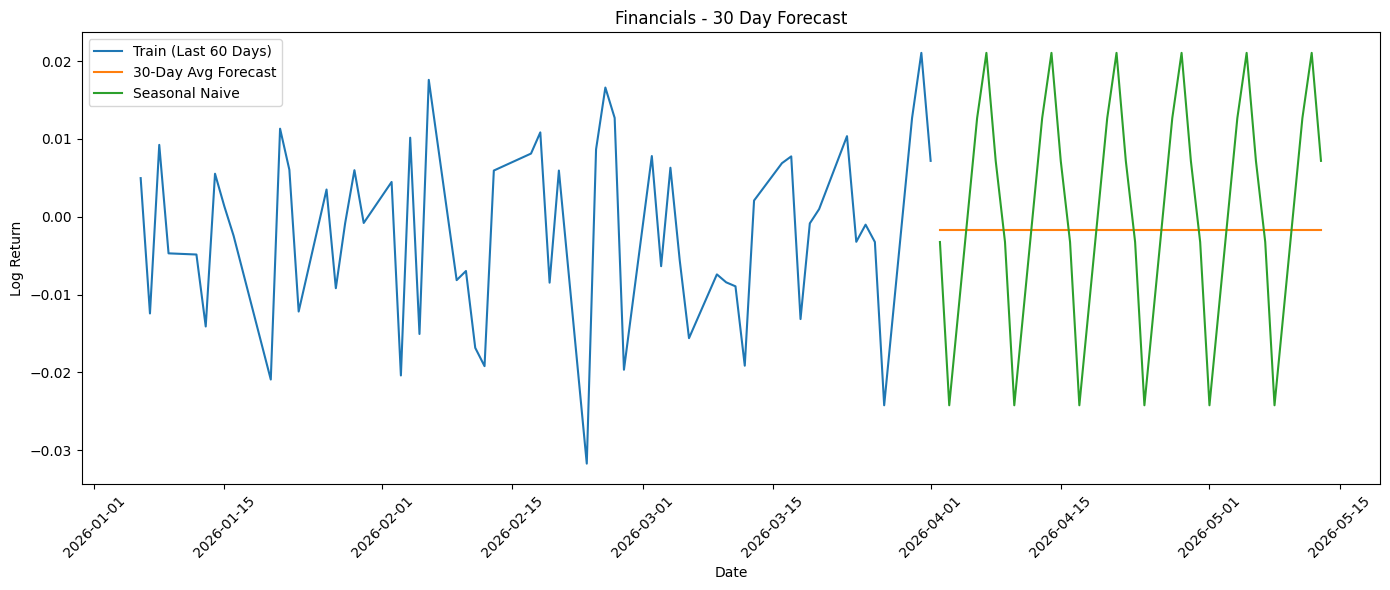

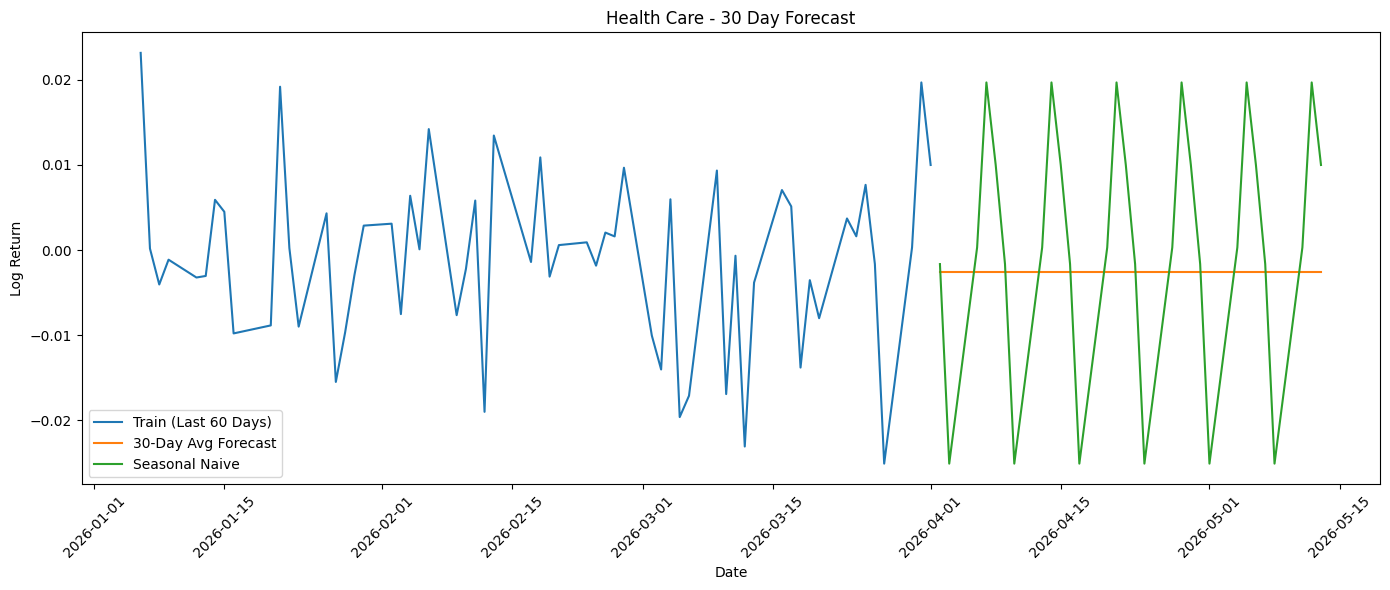

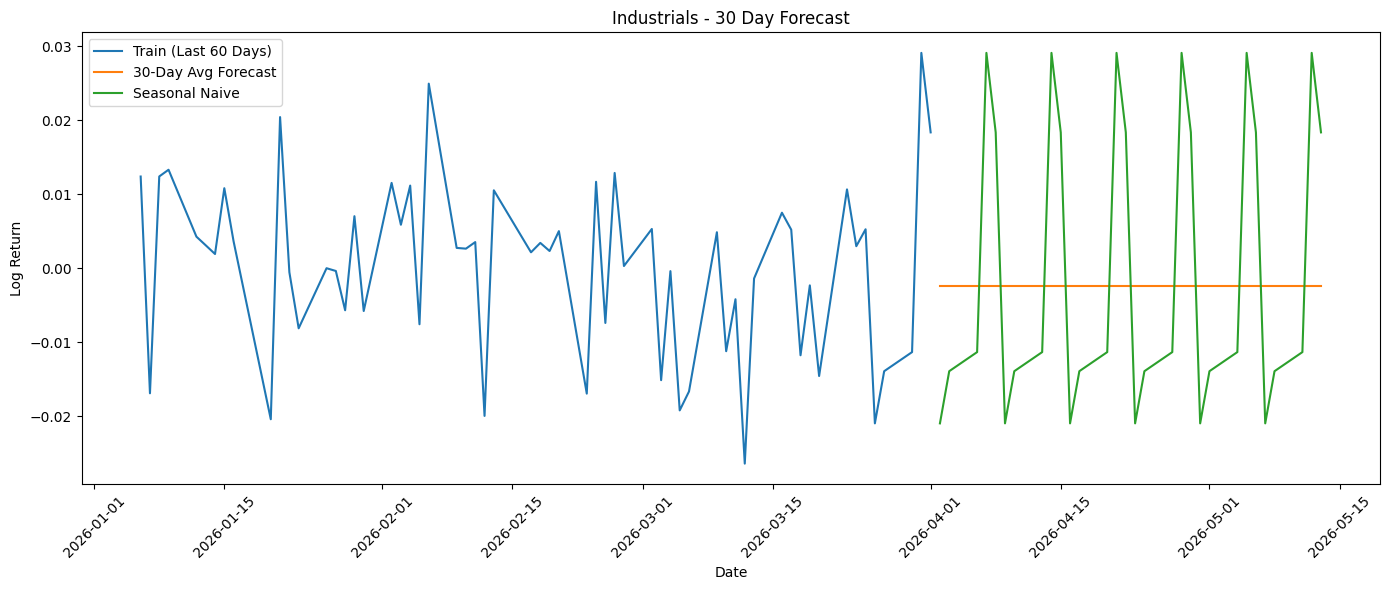

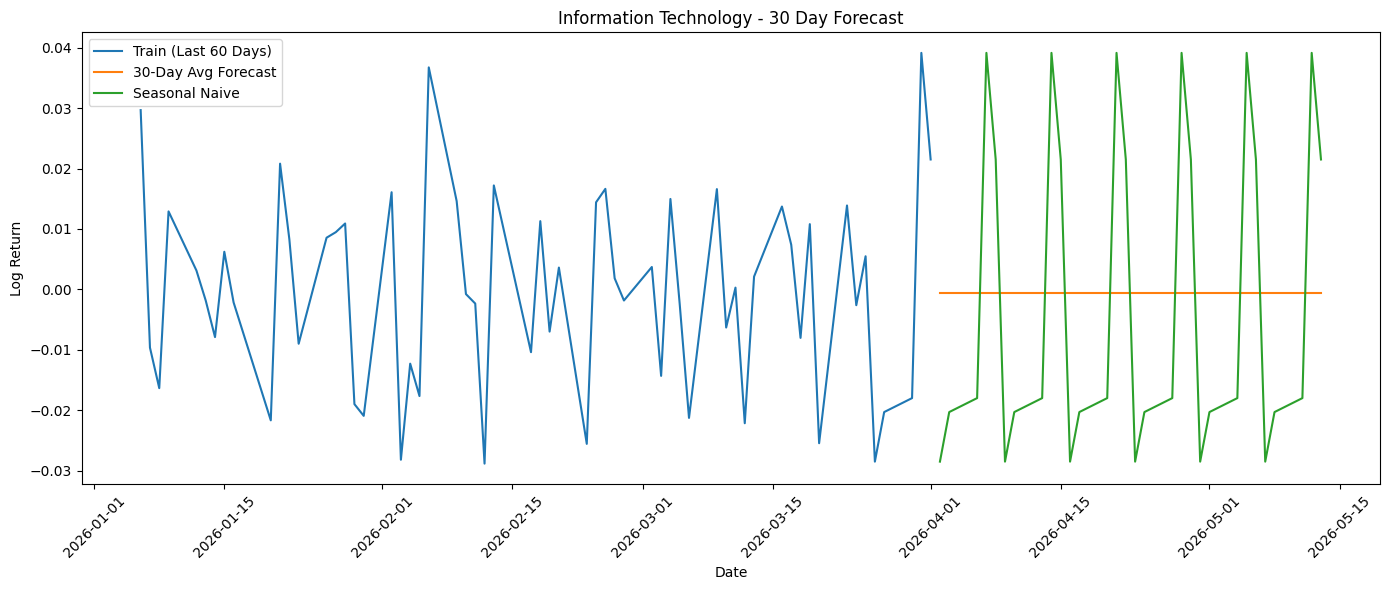

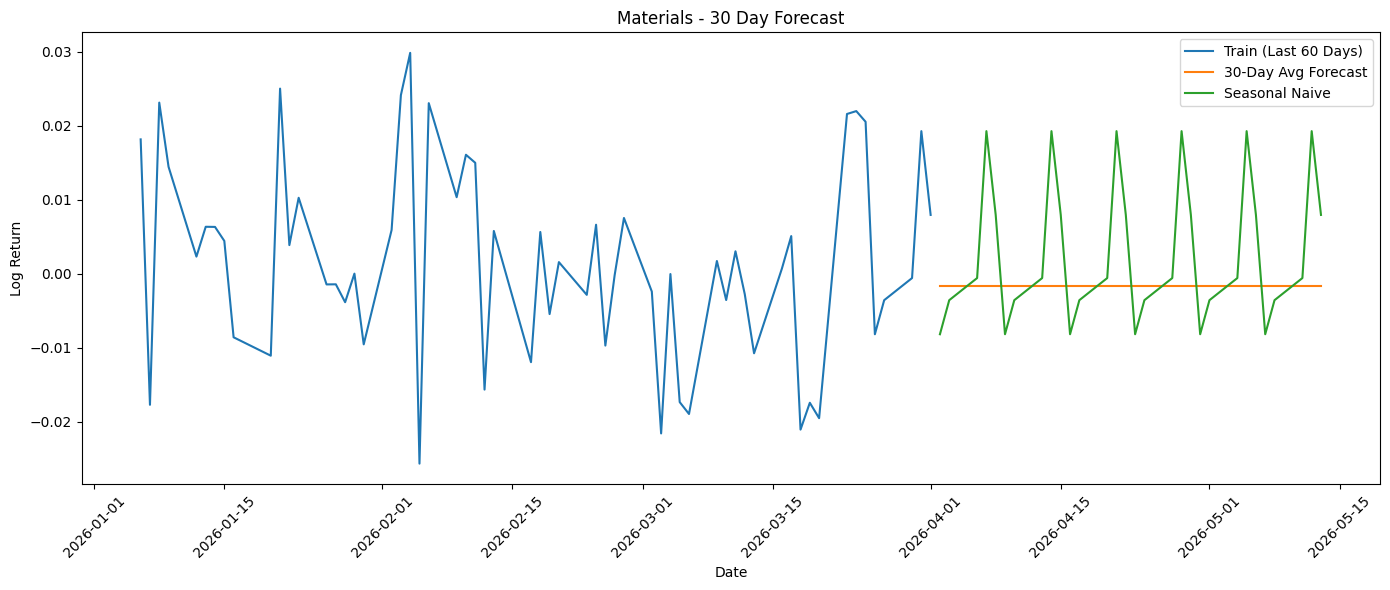

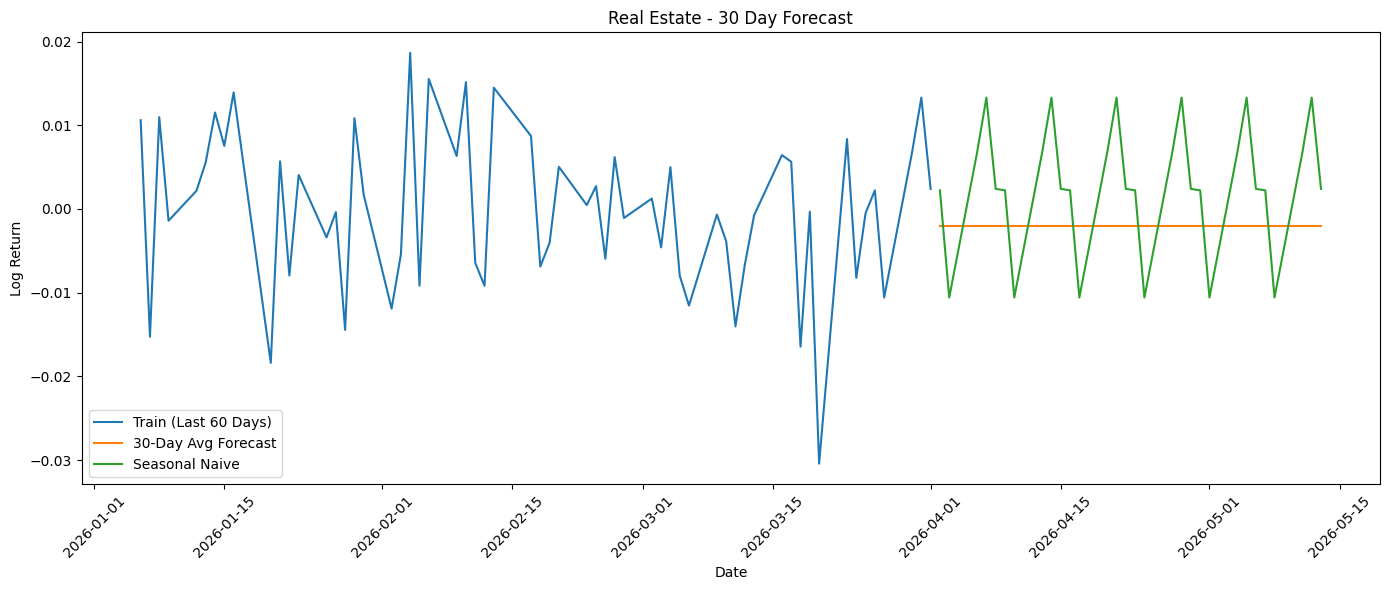

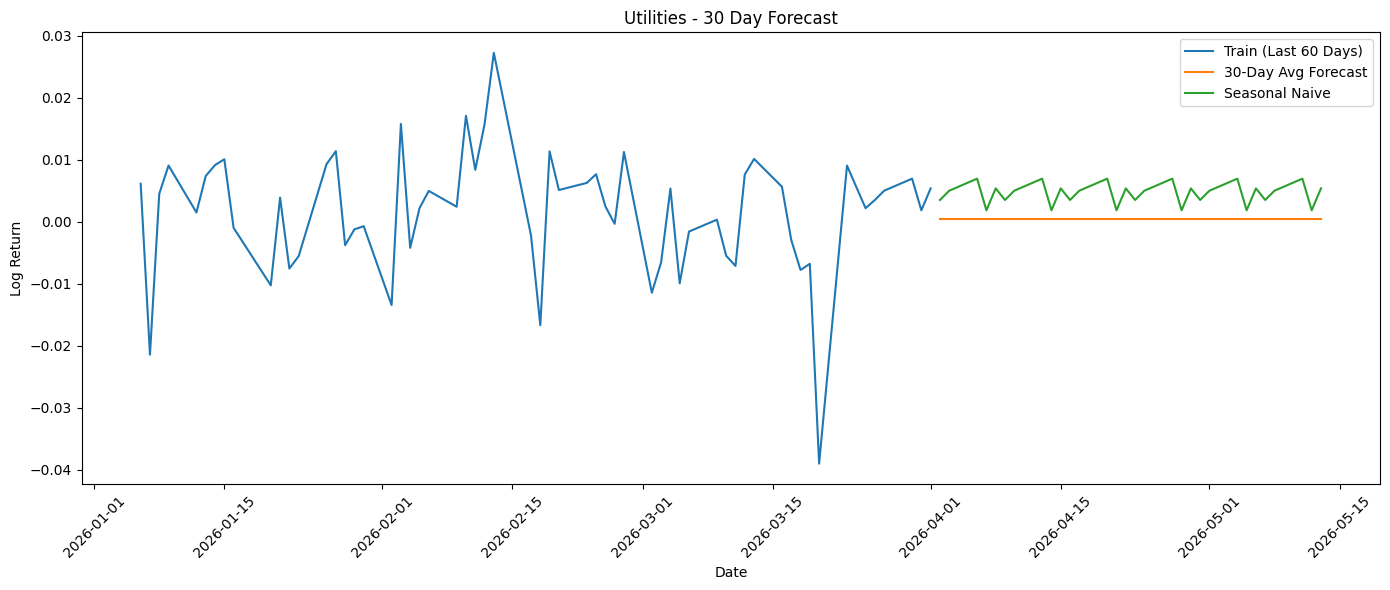

In [38]:
forecast_days = 30

for sector in lr_ts.columns:
    ts = lr_ts[sector].dropna()
    
    train = ts  # use full history (10 years)

    # ---- Forecast horizon (future dates) ----
    future_index = pd.date_range(
        start=ts.index[-1] + pd.Timedelta(days=1),
        periods=forecast_days,
        freq='B'  #business days
    )

    #Baseline (last 30-day avg)
    baseline_forecast = np.repeat(train[-30:].mean(), forecast_days)
    baseline_forecast = pd.Series(baseline_forecast, index=future_index)

    #Seasonal Naive (last 5 trading days)
    last_week = train[-5:].values
    seasonal_naive_forecast = np.tile(last_week, int(np.ceil(forecast_days/5)))[:forecast_days]
    seasonal_naive_forecast = pd.Series(seasonal_naive_forecast, index=future_index)
    plt.figure(figsize=(14, 6))
    
    sns.lineplot(x=train[-60:].index, y=train[-60:].values, label='Train (Last 60 Days)')
    sns.lineplot(x=baseline_forecast.index, y=baseline_forecast.values, label='30-Day Avg Forecast')
    sns.lineplot(x=seasonal_naive_forecast.index, y=seasonal_naive_forecast.values, label='Seasonal Naive')

    plt.title(f"{sector} - 30 Day Forecast")
    plt.xlabel('Date')
    plt.ylabel('Log Return')
    plt.xticks(rotation=45)
    plt.legend()
    plt.tight_layout()
    plt.show()

### Below Code Does the Time Series Forecasting without taking in the entire 10 year data. Instead it tests the model and computes RMSE.

In [39]:
def rmse_metric(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

forecast_days = 30
results = []

for sector in lr_ts.columns:
    ts = lr_ts[sector].dropna()

    train = ts.iloc[:-forecast_days]
    test = ts.iloc[-forecast_days:]
    y_true = test.values
    baseline_pred = np.full(shape=forecast_days,fill_value=train.iloc[-30:].mean())
    baseline_rmse = np.sqrt(mean_squared_error(y_true, baseline_pred))

    last_5 = train.iloc[-5:].values
    seasonal_pred = np.tile(last_5, int(np.ceil(forecast_days / 5)))[:forecast_days]
    seasonal_rmse = np.sqrt(mean_squared_error(y_true, seasonal_pred))

    results.append([sector, "baseline", baseline_rmse])
    results.append([sector, "seasonal_naive", seasonal_rmse])

comparison_df = pd.DataFrame(results, columns=["sector", "method", "rmse"])

### Performance Visualizations For RNN and Random Forest

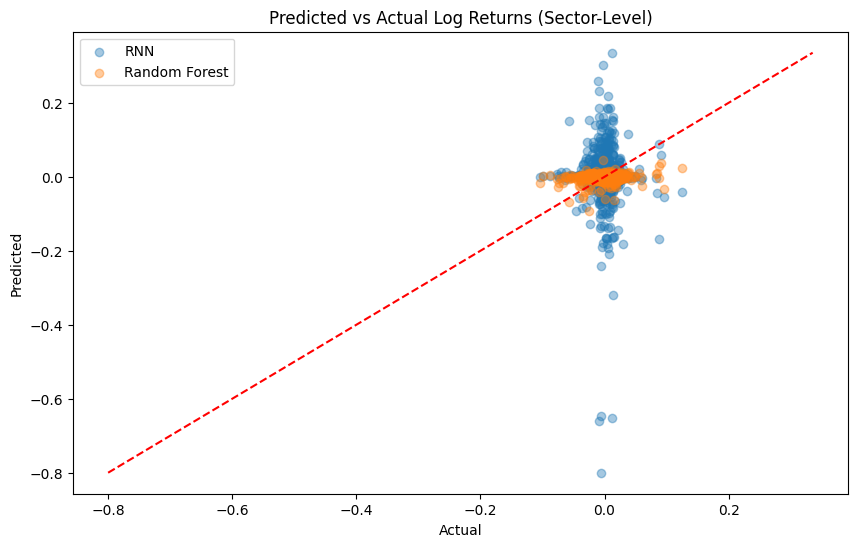

In [43]:
rnn_df = pd.concat(rnn_all, ignore_index=True)
rf_df = pd.concat(rf_all, ignore_index=True)

merged = pd.merge(
    rnn_df,
    rf_df,
    on=["sector", "actual"],
    how="inner"
)
plt.figure(figsize=(10,6))

plt.scatter(merged["actual"], merged["pred_rnn"], alpha=0.4, label="RNN")
plt.scatter(merged["actual"], merged["pred_rf"], alpha=0.4, label="Random Forest")

min_val = min(merged["actual"].min(), merged["pred_rnn"].min(), merged["pred_rf"].min())
max_val = max(merged["actual"].max(), merged["pred_rnn"].max(), merged["pred_rf"].max())

plt.plot([min_val, max_val], [min_val, max_val], "r--")

plt.title("Predicted vs Actual Log Returns (Sector-Level)")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.legend()
plt.show()

### Interpretation For The Graph

- The red line indicates perfect prediction where the actual and predicted log returns match each other perfectly. In an ideal world, I would want the data points to be on the red line. 
- Both RNN and Random Forest data points are clustering around 0 which means they are not learning much. Blue (RNN) points are more spread than the orange (Random Forest) points on the 0 vertical line. RNN might be sensitive to noise and is overfitting while Random forest is averaging log returns and is underfitting.
- All in all, the correlation between actual and predicted log returns for sectors is quite weak. 

### Comparison of RMSEs For All Methods

In [40]:
rnn_df["method"] = "RNN"
rf_df["method"] = "Random Forest"
final_df = pd.concat([comparison_df, rf_df, rnn_df], ignore_index=True)
pivot_df = final_df.pivot_table(
    index="sector",
    columns="method",
    values="rmse",
    aggfunc="mean"
)

print("\n" + "="*80)
print("FORECAST PERFORMANCE COMPARISON (RMSE ONLY)")
print("="*80)

print(pivot_df)


FORECAST PERFORMANCE COMPARISON (RMSE ONLY)
method                       RNN  Random Forest  baseline  seasonal_naive
sector                                                                   
Communication Services  0.025248       0.011039  0.009214        0.016626
Consumer Discretionary  0.018190       0.013412  0.014215        0.014521
Consumer Staples        0.014037       0.009325  0.011728        0.015645
Energy                  0.018071       0.015375  0.013901        0.021359
Financials              0.026658       0.012049  0.012365        0.014916
Health Care             0.027635       0.010311  0.010999        0.014257
Industrials             0.018604       0.012160  0.013668        0.015105
Information Technology  0.039160       0.016136  0.016079        0.019655
Materials               0.019118       0.011830  0.013785        0.017553
Real Estate             0.014895       0.012559  0.009477        0.009905
Utilities               0.073563       0.010326  0.009953        0.

### Interpretation For The RMSE Table

 - Across sectors, the Random Forest model delivers the most consistent performance overall by producing the lowest RMSE or coming very close to the best result. It performs quite well in areas like Financials, Health Care, Industrials, and Materials, where relationships between variables are likely nonlinear. The model seems to handle noisy financial data and shifting market regimes better than the other approaches, which explains its stability across most sectors.

 - The baseline model is surprisingly competitive and even outperforms more complex methods in several cases, including Utilities, Real Estate, and Communication Services. Seasonal naive and RNN models generally underperform, with the RNN showing the weakest results overall, likely due to overfitting and the difficulty of learning stable sequential patterns in highly volatile financial data.

 - From a practical standpoint (and from RMSE results exclusively), Random Forest offers the "best" balance between accuracy and robustness, while the baseline serves as a strong and simple benchmark in more stable sectors. Also, no single model dominates across all conditions. Instead, performance depends heavily on sector characteristics, with simpler models working best in stable environments and more flexible models like Random Forest excelling when relationships are more complex.   

### Table and Graph Conclusion

 - Random Forest showed low correlation between the actual and predicted data points in the graph, which almost makes the RMSE table obsolete. The key takeaway from both the table and the graph is that RMSE can be low and suggest the model is performing well, while in reality the model could be under(over)fitting. This shows how a single metric can be misleading if not paired with actual vs. predicted plots and correlation analysis.

### Ethical Analysis Addressing Bias Risks and Deployment Considerations

- One of the biggest issues that comes with this analysis is that stock prices are inherently unpredictable and are affected by outside factors, which makes it almost impossible to create a consistent trend or pattern. Additionally, the data itself is quite messy, which forced me to normalize prices and use log returns by sector, and I don’t think this captures even half of the actual trends.
- As for bias, there is a very high possibility that temporal bias is present. Since the analysis uses data from the last 10 years, it doesn’t capture larger trends over decades, and it also incorporates crashes or low-interest periods into the trend. In other words, it doesn’t capture large unexpected changes well and instead assumes such changes are part of the trend. Those changes could be part of the trend, but I have no way of confirming either case. The simplifications I had to make (such as averaging log returns) likely further distort these patterns.
- The RMSEs presented above are suspiciously low. I wouldn’t consider using any of these methods to make real decisions. In other words, overconfidence in the model due to seemingly strong metrics (like low RMSE) could cause users to trust and rely on predictions that don’t generalize to real-world conditions. This is especially concerning because the Random Forest model appears to be underfitting (showing low correlation despite the low RMSE), while the RNN shows signs of overfitting. In both cases, the low RMSE gives a misleading impression of strong performance.
- All in all, it’s a good base to test models and see which method and/or engineered feature works best, but not something that should be relied on for real-world deployment without significant improvements and validation.

### Business Recommendations Based On Model Findings

- The most interesting and useful part of the analysis was that many sectors fall considerably in March but grow considerably in November.
- Also, in a given week, many sectors have negative log returns on Thursdays, meaning they experience declines, while they bounce back on Fridays.
- Thus, if this analysis has any truth to it, it may be profitable to buy S&P 500 stocks on Thursdays in March and sell on Fridays in November. However, I’m not fully confident in this since the data had to be heavily simplified (e.g., averaging log returns), which may not capture the full picture. 